# Marketing Funnel & Conversion Analysis

## Objective
Analyze user behavior across the funnel (view → cart → purchase) to identify drop-offs and improve conversion rates.

In [1]:
import pandas as pd
import numpy as np

## Data Loading & Preprocessing

In [2]:
cols = ['event_time', 'event_type', 'product_id', 'category_id', 'user_id']

df = pd.read_csv('2019-Oct.csv', usecols=cols, nrows=400000)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   event_time   400000 non-null  object
 1   event_type   400000 non-null  object
 2   product_id   400000 non-null  int64 
 3   category_id  400000 non-null  int64 
 4   user_id      400000 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 15.3+ MB


In [4]:
df.isnull().sum()

event_time     0
event_type     0
product_id     0
category_id    0
user_id        0
dtype: int64

In [5]:
df = df[df["event_type"].isin(["view", "cart", "purchase"])] #funnel-related events
df["event_time"] = pd.to_datetime(df["event_time"])
df.head(100)

,event_time,event_type,product_id,category_id,user_id
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,541312140
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,554748717
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,519107250
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,550050854
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,535871217
...,...,...,...,...,...
95,2019-10-01 00:01:24+00:00,view,1004785,2053013555631882655,514336739
96,2019-10-01 00:01:25+00:00,view,3900990,2053013552326770905,554748717
97,2019-10-01 00:01:26+00:00,view,15100008,2053013557024391671,519107250
98,2019-10-01 00:01:27+00:00,view,10800076,2053013554994348409,539194858


In [6]:
df['event_type'].value_counts()

event_type
view        385854
purchase      7663
cart          6483
Name: count, dtype: int64

## Dataset Overview

The dataset contains user interaction events from an e-commerce platform. The key event types considered for this analysis are:
- View: User views a product
- Cart: User adds a product to cart
- Purchase: User completes a purchase

Only these relevant events were filtered to construct a meaningful conversion funnel.

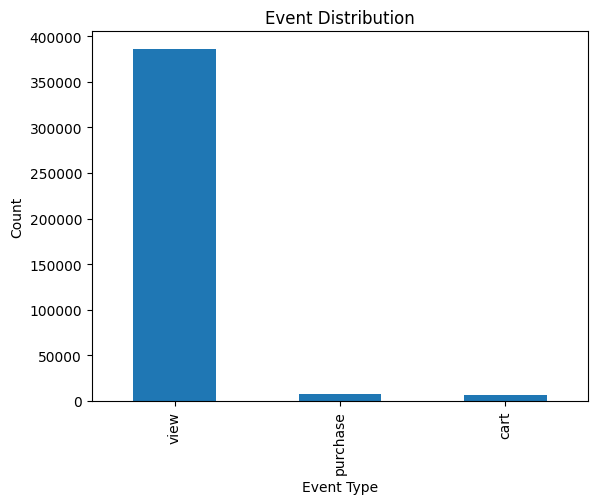

In [7]:
import matplotlib.pyplot as plt

event_counts = df['event_type'].value_counts()

plt.figure()
event_counts.plot(kind='bar')
plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

### Observation

The majority of user activity is concentrated in the "view" stage, accounting for over 95% of total events. This indicates that most users browse products but do not proceed to further stages such as adding items to the cart or making a purchase.

In [8]:
percentages = df['event_type'].value_counts(normalize=True) * 100
print(percentages)

event_type
view        96.46350
purchase     1.91575
cart         1.62075
Name: proportion, dtype: float64


### Observation
Most user activity is concentrated in the "view" stage, indicating that users primarily browse products without engaging further.

In [9]:
df_sorted = df.sort_values(["user_id", "event_time"]) # Sorting the events by user and time
# Keep first occurrence of each event per user
df_first_events = (df_sorted.drop_duplicates(subset=["user_id", "event_type"], keep="first"))
df_first_events.head()

,event_time,event_type,product_id,category_id,user_id
387798,2019-10-01 08:47:35+00:00,view,1003535,2053013555631882655,244951053
1150,2019-10-01 01:32:09+00:00,view,2501614,2053013564003713919,306441847
187167,2019-10-01 05:55:19+00:00,view,17200728,2053013559792632471,321655812
337529,2019-10-01 08:06:33+00:00,view,8901558,2053013553090134275,332550649
139332,2019-10-01 05:10:42+00:00,view,8500409,2053013552259662037,348609428


In [10]:
funnel_counts = {
    "view": df_first_events[df_first_events["event_type"] == "view"]["user_id"].nunique(),
    "cart": df_first_events[df_first_events["event_type"] == "cart"]["user_id"].nunique(),
    "purchase": df_first_events[df_first_events["event_type"] == "purchase"]["user_id"].nunique()
}

funnel_df = (pd.DataFrame.from_dict(funnel_counts, orient="index", columns=["users"]).reset_index().rename(columns={"index": "funnel_stage"}))

# Calculate drop-offs
funnel_df["drop_off"] = funnel_df["users"].shift(1) - funnel_df["users"]
funnel_df["drop_off_percentage"] = funnel_df["drop_off"] / funnel_df["users"].shift(1) * 100

funnel_df

,funnel_stage,users,drop_off,drop_off_percentage
0,view,72901,NaN,NaN
1,cart,3495,69406.0,95.205827
2,purchase,5887,-2392.0,-68.440629


In [11]:
user_events = (
    df_first_events
    .pivot(index="user_id", columns="event_type", values="event_time")
)

user_events.head()

event_type,cart,purchase,view
user_id,,,
244951053,NaT,NaT,2019-10-01 08:47:35+00:00
306441847,NaT,NaT,2019-10-01 01:32:09+00:00
321655812,NaT,NaT,2019-10-01 05:55:19+00:00
332550649,NaT,NaT,2019-10-01 08:06:33+00:00
348609428,NaT,NaT,2019-10-01 05:10:42+00:00


In [12]:
# Users who viewed
view_users = user_events[user_events["view"].notna()]

# Users who viewed AND carted
cart_users = view_users[view_users["cart"].notna()]

# Users who viewed, carted AND purchased
purchase_users = cart_users[cart_users["purchase"].notna()]

## Funnel Construction (User-Level Analysis)

To accurately analyze user behavior, a user-level funnel is constructed. Each user is tracked across stages (view → cart → purchase) in chronological order.

In [13]:
funnel_fixed = pd.DataFrame({
    "funnel_stage": ["view", "cart", "purchase"],
    "users": [
        view_users.shape[0],
        cart_users.shape[0],
        purchase_users.shape[0]
    ]
})

funnel_fixed["drop_off"] = funnel_fixed["users"].shift(1) - funnel_fixed["users"]
funnel_fixed["drop_off_percentage"] = (
    funnel_fixed["drop_off"] / funnel_fixed["users"].shift(1) * 100
)

funnel_fixed

,funnel_stage,users,drop_off,drop_off_percentage
0,view,72901,NaN,NaN
1,cart,3492,69409.0,95.209942
2,purchase,2134,1358.0,38.888889


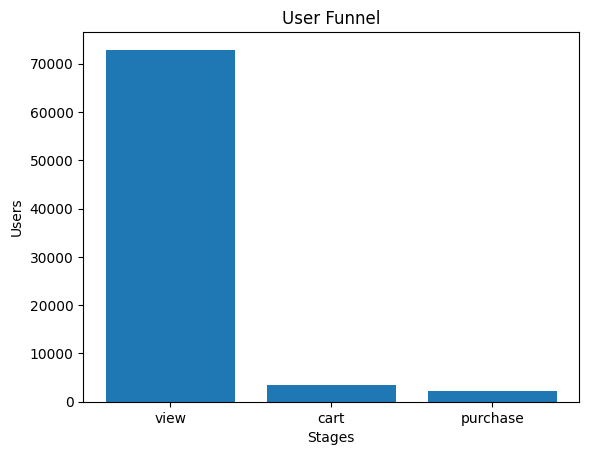

In [14]:
stages = funnel_fixed['funnel_stage']
values = funnel_fixed['users']

plt.figure()
plt.bar(stages, values)
plt.title("User Funnel")
plt.xlabel("Stages")
plt.ylabel("Users")
plt.show()

In [15]:
funnel_fixed.shape

(3, 4)

In [16]:
# Users who viewed and carted
view_cart_users = cart_users.copy()

# Time taken from view to cart
view_cart_users["view_to_cart_time"] = (
    view_cart_users["cart"] - view_cart_users["view"]
).dt.total_seconds() / 60  # minutes

view_cart_users["view_to_cart_time"].describe()

count    3492.000000
mean       17.071158
std        45.289871
min       -47.966667
25%         0.579167
50%         1.716667
75%         7.958333
max       376.250000
Name: view_to_cart_time, dtype: float64

In [17]:
# Remove negative or zero time differences
view_cart_users = view_cart_users[
    view_cart_users["view_to_cart_time"] > 0
]

view_cart_users["view_to_cart_time"].describe()

count    3483.000000
mean       17.130802
std        45.326853
min         0.050000
25%         0.583333
50%         1.733333
75%         7.991667
max       376.250000
Name: view_to_cart_time, dtype: float64

In [18]:
# Create time-based segments
view_cart_users["speed_segment"] = pd.cut(
    view_cart_users["view_to_cart_time"],
    bins=[0, 2, 10, np.inf],
    labels=["fast", "medium", "slow"]
)

view_cart_users["speed_segment"].value_counts(normalize=True) * 100

speed_segment
fast      52.856733
medium    25.208154
slow      21.935113
Name: proportion, dtype: float64

In [19]:
view_to_cart = (funnel_fixed.loc[1, "users"] / funnel_fixed.loc[0, "users"]) * 100
cart_to_purchase = (funnel_fixed.loc[2, "users"] / funnel_fixed.loc[1, "users"]) * 100

print("view_to_cart : ",view_to_cart)
print("cart_to_purchase: ",cart_to_purchase)

view_to_cart :  4.790057749550761
cart_to_purchase:  61.111111111111114


In [20]:
funnel_fixed

,funnel_stage,users,drop_off,drop_off_percentage
0,view,72901,NaN,NaN
1,cart,3492,69409.0,95.209942
2,purchase,2134,1358.0,38.888889


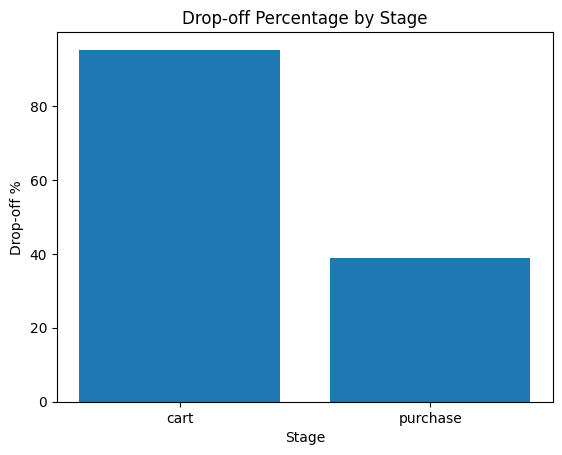

In [21]:
plt.figure()
plt.bar(funnel_fixed['funnel_stage'], funnel_fixed['drop_off_percentage'])
plt.title("Drop-off Percentage by Stage")
plt.xlabel("Stage")
plt.ylabel("Drop-off %")
plt.show()

### Observation

The highest drop-off occurs at the View → Cart stage, highlighting a major bottleneck in the funnel. In contrast, the Cart → Purchase stage shows a lower drop-off, indicating that users who add items to the cart have a higher likelihood of completing the purchase.

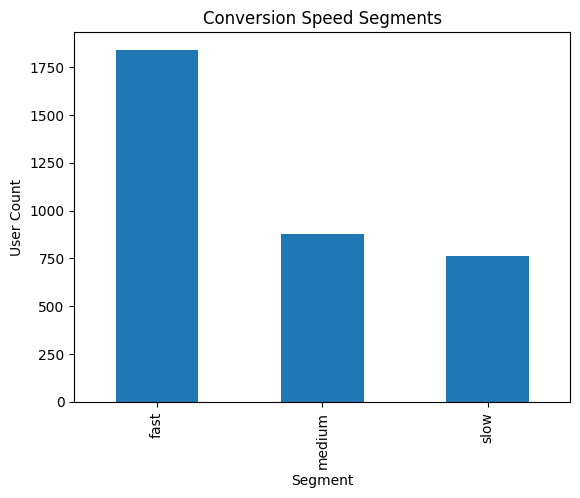

In [22]:
view_cart_users['speed_segment'].value_counts().plot(kind='bar')

plt.title("Conversion Speed Segments")
plt.xlabel("Segment")
plt.ylabel("User Count")
plt.show()

### Observation
Users are distributed across fast, medium, and slow conversion segments, indicating varying levels of purchase intent and decision-making time.

## Final Conclusion

The analysis reveals that the primary bottleneck in the marketing funnel occurs at the View → Cart stage, where the majority of users drop off. Despite strong performance in the Cart → Purchase stage, the low engagement at the initial stage significantly impacts overall conversion rates.

Improving user engagement during the early stages of the funnel can lead to substantial improvements in overall performance.

## Recommendations

- Improve product page quality by enhancing images, descriptions, and customer reviews  
- Optimize the visibility and design of the "Add to Cart" button  
- Introduce urgency through discounts, limited-time offers, or stock indicators  
- Implement retargeting strategies for users who view products but do not proceed further  
- Provide personalized recommendations to increase user engagement  